# P7demo - Supplément GRETA - `scikit-learn`

## Importation des librairies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Chargement des onglets du fichier Excel

In [2]:
data = pd.read_excel("data/sanitoral-headers-clean.xlsx", sheet_name=None)

In [3]:
print(*data.keys(), sep = "\n")

Projects_plans
Project type
Actual_Costs
Actual_Duration
Actual_Delivrable
Projects_Locations
Country_Profiles


In [4]:
df_projects_plans     = data["Projects_plans"]
df_project_type       = data["Project type"]
df_actual_costs       = data["Actual_Costs"]
df_actual_duration    = data["Actual_Duration"]
df_actual_deliverable = data["Actual_Delivrable"]
df_projects_locations = data["Projects_Locations"]
df_country_profiles   = data["Country_Profiles"]

In [5]:
df_projects_plans.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Project ID          520 non-null    int64         
 1   Phase               520 non-null    str           
 2   Start Date          520 non-null    datetime64[us]
 3   Planned_Duration    520 non-null    int64         
 4   Planned_Cost        520 non-null    int64         
 5   Planned_Delivrable  520 non-null    int64         
dtypes: datetime64[us](1), int64(4), str(1)
memory usage: 24.5 KB


In [6]:
print(*sorted(pd.unique(df_projects_plans["Phase"])), sep="\n")

Phase 1 - Planning
Phase 2 - Initiation
Phase 3 - Implementation
Phase 4 - Manufacturing
Phase A - Initiation
Phase B - Preparation
Phase C - Development
Phase D - Testing
Phase E - Deployment
Phase F - Post-deployment


In [7]:
df_actual_duration.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Project ID       520 non-null    int64
 1   Phase            520 non-null    str  
 2   Actual_Duration  520 non-null    int64
dtypes: int64(2), str(1)
memory usage: 12.3 KB


In [8]:
print(*sorted(pd.unique(df_actual_duration["Phase"])), sep="\n")

Phase 1 - Planning
Phase 2 - Initiation
Phase 3 - Implementation
Phase 4 - Manufacturing
Phase A - Initiation
Phase B - Preparation
Phase C - Development
Phase D - Testing
Phase E - Deployment
Phase F - Post-deployment


## Jointure

In [9]:
df_merge = pd.merge(df_projects_plans, df_actual_duration)

In [10]:
df_merge.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Project ID          520 non-null    int64         
 1   Phase               520 non-null    str           
 2   Start Date          520 non-null    datetime64[us]
 3   Planned_Duration    520 non-null    int64         
 4   Planned_Cost        520 non-null    int64         
 5   Planned_Delivrable  520 non-null    int64         
 6   Actual_Duration     520 non-null    int64         
dtypes: datetime64[us](1), int64(5), str(1)
memory usage: 28.6 KB


## Calculs

In [11]:
df_merge["Delay"]         = (df_merge["Actual_Duration"] - df_merge["Planned_Duration"]).clip(lower=0)
df_merge["Is_Late"]       = (df_merge["Delay"] > 0)
df_merge["Start_Month"]   = df_merge["Start Date"].dt.month
df_merge["Start_Quarter"] = df_merge["Start Date"].dt.quarter
df_merge["Start_Year"]    = df_merge["Start Date"].dt.year

## Agrégation

In [12]:
df_project = df_merge.groupby("Project ID").agg({
    "Planned_Duration": "sum",
    "Planned_Cost": "sum",
    "Planned_Delivrable": "sum",
    "Phase": "count",
    "Delay": "sum",
    "Is_Late": "any",
    "Start Date": "min",
})
df_project["Start_Month"]   = df_project["Start Date"].dt.month
df_project["Start_Quarter"] = df_project["Start Date"].dt.quarter
df_project["Start_Year"]    = df_project["Start Date"].dt.year
df_project

,Planned_Duration,Planned_Cost,Planned_Delivrable,Phase,Delay,Is_Late,Start Date,Start_Month,Start_Quarter,Start_Year
Project ID,,,,,,,,,,
1,469,750000,76,4,3,True,2018-01-16,1,1,2018
2,365,1500000,71,4,54,True,2018-01-30,1,1,2018
3,398,750000,73,4,108,True,2018-03-03,3,1,2018
4,151,750000,95,4,157,True,2018-04-02,4,2,2018
5,435,750000,59,4,14,True,2018-01-19,1,1,2018
...,...,...,...,...,...,...,...,...,...,...
100,606,91200,95,6,109,True,2020-05-21,5,2,2020
101,539,121200,96,6,47,True,2020-01-16,1,1,2020
102,612,85200,70,6,6,True,2020-03-20,3,1,2020


## Visualisation

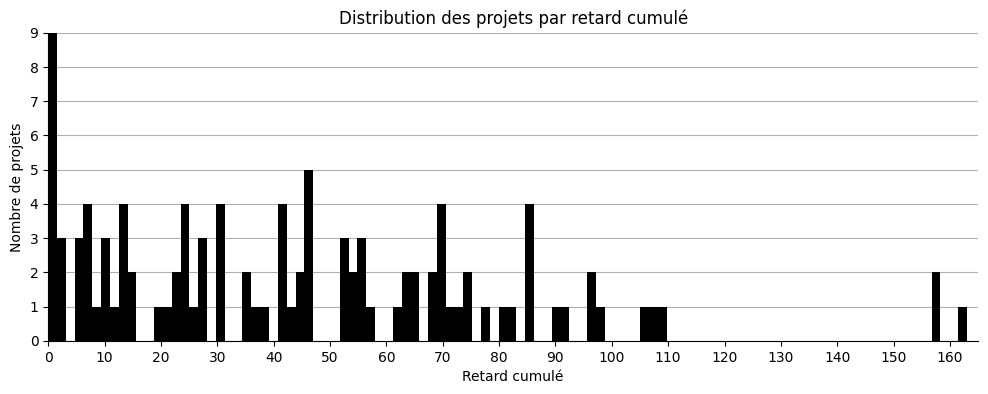

In [13]:
ax = df_project[["Delay"]].plot.hist(bins=df_project.shape[0], legend=False, color="black", figsize=(12,4))
plt.title("Distribution des projets par retard cumulé")
plt.ylabel("Nombre de projets")
plt.xlabel("Retard cumulé")
plt.xlim(0, 165)
plt.ylim(0, 9)
plt.xticks(range(0,165,10))
plt.yticks(range(10))
plt.grid(axis="y")
ax.set_axisbelow(True)
ax.spines["top"  ].set_visible(False)
ax.spines["right"].set_visible(False)
plt.show()